In [1]:
# standard library imports
import csv
import ast
import datetime as dt
import json
import os
import statistics
import time

import matplotlib.pyplot as plt
import seaborn as sns
# third-party imports
import numpy as np
import pandas as pd
import requests
from collections import Counter 
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import sklearn.metrics as metrics
import sklearn.cluster as cluster
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from google.colab import files

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
np.random.seed(0)

In [7]:
cd drive/MyDrive/SENG\ 474

/content/drive/.shortcut-targets-by-id/1GYoSGH0DhRgXvClJVjYAXQJSJujIKfwl/SENG 474


In [24]:
# inspect downloaded steamspy data
# df = pd.read_csv('d:/CSC503/project/out_v2.csv')
df = pd.read_csv('out_v2.csv')
# app_list = pd.read_csv('d:/CSC503/project/app_list.csv')

In [9]:
df.head(5)

,type,name,steam_appid,is_free,controller_support,short_description,header_image,developers,publishers,demos,...,windows,French,English,German,Indie,Casual,Action,Single,Cloud,Achievements
0,game,Rag Doll Kung Fu,1002,0,0,A piece of Steam history - THE FIRST EVER NON ...,https://cdn.akamai.steamstatic.com/steam/apps/...,Mark Healey,Mark Healey,1,...,1,0,1,0,1,0,1,1,0,0
1,game,Red Orchestra: Ostfront 41-45,1200,0,0,Fight in the theatre of war that changed the w...,https://cdn.akamai.steamstatic.com/steam/apps/...,Tripwire Interactive,Tripwire Interactive,0,...,1,1,1,0,0,0,0,0,0,1
2,game,SiN Episodes: Emergence,1300,0,0,"You are John Blade, commander of HardCorps, an...",https://cdn.akamai.steamstatic.com/steam/apps/...,Ritual Entertainment,Ritual Entertainment,0,...,1,1,1,0,0,0,0,1,0,0
3,game,SiN Episodes: Emergence,1300,0,0,"You are John Blade, commander of HardCorps, an...",https://cdn.akamai.steamstatic.com/steam/apps/...,Ritual Entertainment,Ritual Entertainment,0,...,1,1,1,0,0,0,0,1,0,0
4,game,SiN: Gold,1313,0,0,SiN: Gold has returned! Free update for origin...,https://cdn.akamai.steamstatic.com/steam/apps/...,"Ritual Entertainment, Nightdive Studios",Nightdive Studios,0,...,1,1,1,0,0,0,0,1,0,0


In [10]:
df.shape

(64503, 37)

Unused column and na

In [39]:
new_df = df.drop(columns = ["type","name","short_description"
                            ,'developers', 'publishers'
                            ,'header_image','screenshots'
                            ,'owners'])
new_df = new_df.dropna()
new_df.head(5)

,steam_appid,is_free,controller_support,demos,price_overview,metacritic,movies,recommendations,achievements,released 10 years ago,...,windows,French,English,German,Indie,Casual,Action,Single,Cloud,Achievements
0,1002,0,0,1,119,69.0,0,0,0,1,...,1,0,1,0,1,0,1,1,0,0
1,1200,0,0,0,569,81.0,0,1278,44,1,...,1,1,1,0,0,0,0,0,0,1
2,1300,0,0,0,1149,75.0,0,550,0,1,...,1,1,1,0,0,0,0,1,0,0
3,1300,0,0,0,1149,75.0,0,550,0,1,...,1,1,1,0,0,0,0,1,0,0
5,1500,0,1,0,1149,84.0,1,642,0,1,...,1,1,1,1,1,0,1,1,1,0


In [ ]:
keep_df = new_df

In [40]:
new_df.columns

Index(['steam_appid', 'is_free', 'controller_support', 'demos',
       'price_overview', 'metacritic', 'movies', 'recommendations',
       'achievements', 'released 10 years ago', 'content_descriptors',
       'average_forever', 'average_2weeks', 'median_forever', 'median_2weeks',
       'ccu', 'percent_positive', 'linux', 'mac', 'windows', 'French',
       'English', 'German', 'Indie', 'Casual', 'Action', 'Single', 'Cloud',
       'Achievements'],
      dtype='object')

In [41]:
to_predict = ['ccu','percent_positive','price_overview']
# ,'owners', 
not_column = new_df.drop(columns = to_predict)
labels_df = new_df[to_predict]
X_train, X_test, y_train, y_test = train_test_split(new_df,labels_df, test_size=0.7)

Reference: https://machinelearningknowledge.ai/tutorial-for-k-means-clustering-in-python-sklearn/#:~:text=Step%2D1%3ATo%20decide%20the,new%20centroid%20for%20every%20cluster.

Because PCA is sensitive to the scale, if we normalized each feature by MinxMaxScaler we can see a better result.

In [42]:
scaler = MinMaxScaler()
scale = scaler.fit_transform(X_train[to_predict])
df_scale = pd.DataFrame(scale, columns = to_predict);
scale_test = scaler.fit_transform(X_test)
df_scale.head(5)

,ccu,percent_positive,price_overview
0,0.010954,0.503765,0.149500
1,0.000068,0.018236,0.145226
2,0.000135,0.097734,0.196513
3,0.004598,0.062888,0.341824
4,0.000473,0.057465,0.066587


PCA dimesion reduction

In [43]:
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(df_scale)
pca_df = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
pca_df.head()

,principal component 1,principal component 2
0,0.032576,0.435223
1,-0.015729,-0.047869
2,0.042173,0.026472
3,0.183585,-0.021493
4,-0.090183,-0.001532


TESTING WITH 4 CLUSTERS

In [44]:
km=KMeans(n_clusters=4)
y_predicted = km.fit_predict(X_train[to_predict])
y_predicted

array([3, 3, 3, ..., 0, 0, 3], dtype=int32)

In [45]:
km.cluster_centers_

array([[2.03045267e+01, 5.85747345e+00, 7.95384774e+02],
       [1.41990566e+02, 6.98550093e+00, 3.97814151e+03],
       [1.49300000e+03, 6.93549910e+00, 7.58025000e+03],
       [2.72415459e+01, 8.31921832e+00, 2.15658696e+03]])

In [46]:
km.labels_

array([3, 3, 3, ..., 0, 0, 3], dtype=int32)

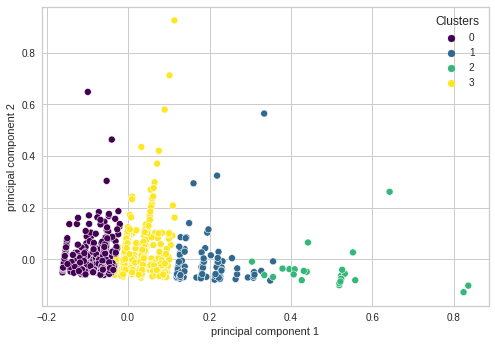

In [53]:
pca_df['Clusters'] = km.labels_
sc = sns.scatterplot(x="principal component 1", y="principal component 2",hue = 'Clusters',  data=pca_df,palette='viridis')
# fig = sc.get_figure()
# fig.savefig("scatter1.png") 
# files.download("scatter1.png") 

FIND optimal cluster 

The Silhouette Method

In [48]:
K=range(2,30)
wss = []
for k in K:
    kmeans=cluster.KMeans(n_clusters=k)
    kmeans=kmeans.fit(pca_df)
    wss_iter = kmeans.inertia_
    wss.append(wss_iter)

In [35]:
for i in range(2,30):
  labels=cluster.KMeans(n_clusters=i,random_state=200).fit(df_scale).labels_
  print ("Silhouette score for k(clusters) = "+str(i)+" is "
  +str(metrics.silhouette_score(df_scale,labels,metric="euclidean",sample_size=1000,random_state=200)))

Silhouette score for k(clusters) = 2 is 0.4514589172174695
Silhouette score for k(clusters) = 3 is 0.49832890888587544
Silhouette score for k(clusters) = 4 is 0.42571881826700975
Silhouette score for k(clusters) = 5 is 0.4453495788411919
Silhouette score for k(clusters) = 6 is 0.409323573663586
Silhouette score for k(clusters) = 7 is 0.36543253888447164
Silhouette score for k(clusters) = 8 is 0.3974486137417042
Silhouette score for k(clusters) = 9 is 0.39493726088342307
Silhouette score for k(clusters) = 10 is 0.39879028785495074
Silhouette score for k(clusters) = 11 is 0.38136792861939467
Silhouette score for k(clusters) = 12 is 0.38234781976818505
Silhouette score for k(clusters) = 13 is 0.38955857693755697
Silhouette score for k(clusters) = 14 is 0.3920059648114548
Silhouette score for k(clusters) = 15 is 0.3924495417530793
Silhouette score for k(clusters) = 16 is 0.39680911384641093
Silhouette score for k(clusters) = 17 is 0.39652941389539775
Silhouette score for k(clusters) = 18 i

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

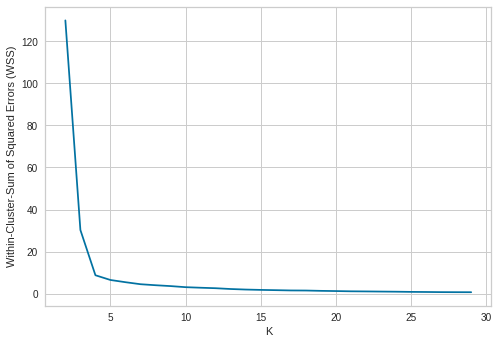

In [52]:
plt.xlabel('K')
plt.ylabel('Within-Cluster-Sum of Squared Errors (WSS)')
plt.plot(K,wss)
# plt.savefig("wss.png")
# files.download("wss.png") 

Reference: https://towardsdatascience.com/cheat-sheet-to-implementing-7-methods-for-selecting-optimal-number-of-clusters-in-python-898241e1d6ad

Elbow Method

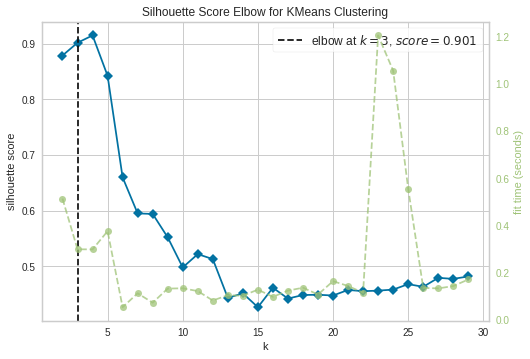

In [54]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,30),metric='silhouette', timings= True)
visualizer.fit(pca_df)
visualizer.show(outpath="elbow.png")

Use cluster 3

In [55]:
kmeans = cluster.KMeans(n_clusters=3,init="k-means++")
kmeans = kmeans.fit(pca_df)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

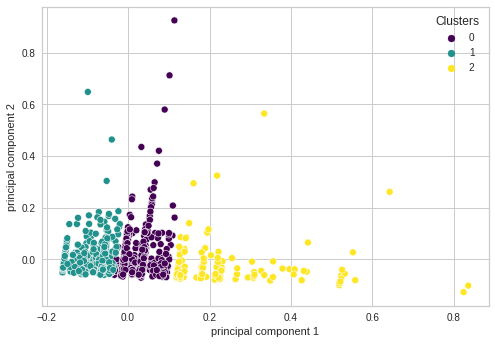

In [56]:
pca_df['Clusters'] = kmeans.labels_
opti = sns.scatterplot(x="principal component 1", y="principal component 2",hue = 'Clusters',  data=pca_df,palette='viridis')

fig = opti.get_figure()
fig.savefig("scatter2.png") 
files.download("scatter2.png") 